In [45]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import pfhedge
from pfhedge.instruments import BrownianStock
from pfhedge.instruments import EuropeanOption

from pfhedge.nn import Hedger
from pfhedge.nn import MultiLayerPerceptron
from pfhedge.nn.functional import entropic_risk_measure
from pfhedge.nn import BlackScholes
from pfhedge.features._base import StateIndependentFeature




In [24]:
torch.manual_seed(6)
N_PATHS = 50000
N_EPOCHS = 100

In [25]:
data = pd.read_csv("IBM.csv")
data["Date"] = pd.to_datetime(data["Date"])

In [26]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13642 entries, 0 to 13641
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Unnamed: 0  13642 non-null  int64         
 1   Date        13642 non-null  datetime64[us]
 2   Open_IBM    13642 non-null  float64       
 3   High_IBM    13642 non-null  float64       
 4   Low_IBM     13642 non-null  float64       
 5   Close_IBM   13642 non-null  float64       
 6   Volume_IBM  13642 non-null  int64         
dtypes: datetime64[us](1), float64(4), int64(2)
memory usage: 746.2 KB


In [27]:
T_start = len(data)-100

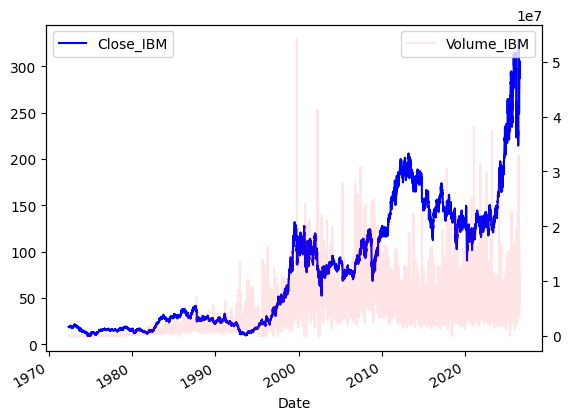

In [28]:
ax1 = data.plot(x="Date", y="Close_IBM", color="blue")
ax2 = ax1.twinx()
data.plot(x="Date", y="Volume_IBM", ax=ax2, color="red",alpha=0.1)
plt.show()

In [29]:
prices = data["Close_IBM"].iloc[T_start:]

s0 = float(prices.iloc[0])
prices_normalized = prices / s0

x1 = np.log(prices_normalized).diff().dropna()


In [30]:
daily_mean = x1.mean()
daily_vol = x1.std(ddof=1)

sigma = daily_vol * np.sqrt(250)
mu = daily_mean * 250 + 0.5 * sigma**2

stock_GBM = BrownianStock(
    mu=0,
    sigma=sigma,
    dt=1 / 250,
)


In [31]:
K = 1
print(K)

1


torch.Size([50000, 100])

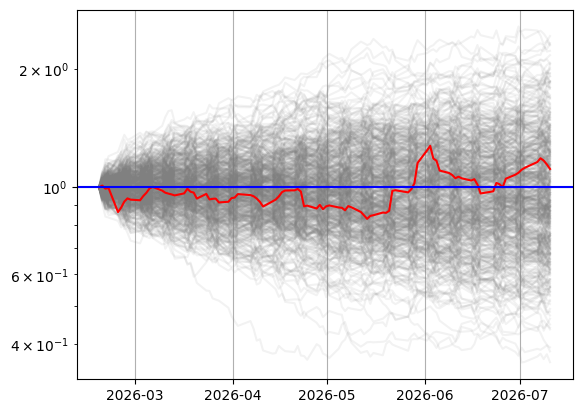

In [32]:
stock_GBM.simulate(n_paths=N_PATHS, time_horizon = len(x1) / 250) 
paths_GBM = stock_GBM.spot

plt.plot(data["Date"][T_start:],paths_GBM[0:500].T,alpha=0.1,color="grey")
plt.plot(data["Date"][T_start:],prices_normalized,color="red")
plt.axhline(K,color="blue")
plt.yscale("log")
plt.grid()
paths_GBM.shape

{'pricer': None, 'cost': 0.0, '_clauses': OrderedDict(), '_underliers': OrderedDict([('underlier', BrownianStock(sigma=0.5201, dt=0.0040))]), 'call': True, 'strike': 1, 'maturity': 0.08}


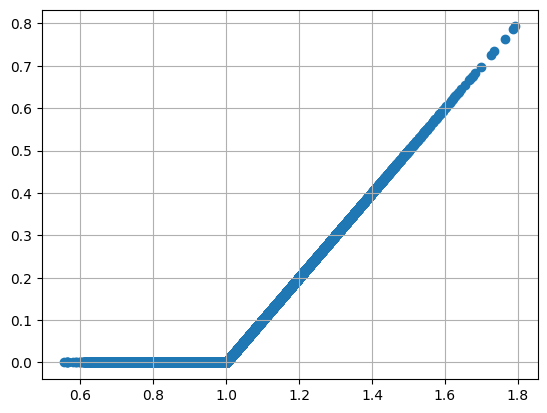

In [33]:
EuropeanCallOption = EuropeanOption(stock_GBM,strike=K,maturity=20/250)
derivative = EuropeanCallOption

print(EuropeanCallOption.__dict__)
EuropeanCallOption.simulate(N_PATHS) # Runs MonteCarlo simulation for the option
payoff = EuropeanCallOption.payoff_fn()
underlying = EuropeanCallOption.ul() # ul() returns the underlying asset
prices = underlying.spot[:,-1]       # Extracts the stock price at expiration
plt.scatter(prices,payoff)
plt.grid()

In [46]:
def fourier_features(log_path, K=3):
    coefficients = torch.fft.rfft(
        log_path,
        dim=-1,
        norm="ortho",
    )

    dc = coefficients[..., :1].real
    harmonics = coefficients[..., 1:K + 1]

    return torch.cat(
        [
            dc,
            harmonics.real,
            harmonics.imag,
        ],
        dim=-1,
    )


class RollingFourierFeature(StateIndependentFeature):
    def __init__(self, history_prices, K=3):
        super().__init__()

        history = torch.as_tensor(
            np.asarray(history_prices),
            dtype=torch.get_default_dtype(),
        )

        if history.ndim != 1:
            raise ValueError("history_prices must be one-dimensional")

        if torch.any(history <= 0):
            raise ValueError("history_prices must be positive")

        self.history_log_relative = torch.log(history / history[-1])
        self.window = history.numel()
        self.K = K

        if K >= self.window // 2 + 1:
            raise ValueError("K is too large for the history window")

    def __str__(self):
        return f"rolling_fourier_{self.K}"

    def get(self, time_step=None):
        spot = self.derivative.ul().spot
        log_spot = torch.log(spot)

        history = self.history_log_relative.to(spot)
        log_strike = spot.new_tensor(self.derivative.strike).log()

        # Align historical data so its final value equals simulated S_0
        historical_log_moneyness = (
            history[:-1].unsqueeze(0)
            + log_spot[:, :1]
            - log_strike
        )

        simulated_log_moneyness = log_spot - log_strike

        complete_path = torch.cat(
            [
                historical_log_moneyness.expand(spot.shape[0], -1),
                simulated_log_moneyness,
            ],
            dim=1,
        )

        # Shape: (n_paths, n_times, history_window)
        rolling_windows = complete_path.unfold(
            dimension=1,
            size=self.window,
            step=1,
        )

        features = fourier_features(
            rolling_windows,
            K=self.K,
        )

        if time_step is not None:
            features = features[:, time_step:time_step + 1, :]

        return features

In [47]:
K = 3
fourier_feature = RollingFourierFeature(
    history_prices=prices,
    K=K,
)

model1f = MultiLayerPerceptron(
    in_features=1 + 2 * K,
    n_units=16,
    n_layers=3,
)

hedger1f = Hedger(
    model1f,
    inputs=[fourier_feature],
)

print(hedger1f)
print(hedger1f.model)

Hedger(
  inputs=['rolling_fourier_3']
  (model): MultiLayerPerceptron(
    (0): Linear(in_features=7, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Identity()
  )
  (criterion): EntropicRiskMeasure()
)
MultiLayerPerceptron(
  (0): Linear(in_features=7, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=16, bias=True)
  (5): ReLU()
  (6): Linear(in_features=16, out_features=1, bias=True)
  (7): Identity()
)


In [48]:
model1 = MultiLayerPerceptron(
    in_features=3,
    n_units=16,
    n_layers=3,
)




hedger1 = Hedger(model1, inputs=["log_moneyness", "expiry_time", "volatility"])

print(hedger1)
print(hedger1.model)

Hedger(
  inputs=['log_moneyness', 'expiry_time', 'volatility']
  (model): MultiLayerPerceptron(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Identity()
  )
  (criterion): EntropicRiskMeasure()
)
MultiLayerPerceptron(
  (0): Linear(in_features=3, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=16, bias=True)
  (5): ReLU()
  (6): Linear(in_features=16, out_features=1, bias=True)
  (7): Identity()
)


In [49]:
class IndependentNets(nn.Module):
    def __init__(self, N):
        super().__init__()
        self.nets = nn.ModuleList([
            MultiLayerPerceptron(
                in_features=3,
                n_units=16,
                n_layers=3,
            )
            for _ in range(N)
        ])

    def forward(self, x):
        # x has shape (n_paths, N + 1, 3)
        outputs = [
            net(x[..., i:i + 1, :])
            for i, net in enumerate(self.nets)
        ]

        # PFHedge expects an output at maturity too
        return torch.cat(outputs + [outputs[-1]], dim=-2)


N = derivative.ul().spot.shape[-1] - 1

modelN = IndependentNets(N)

hedgerN = Hedger(
    modelN,
    inputs=["log_moneyness", "expiry_time", "volatility"],
)

print(hedgerN)
print(hedgerN.model)

Hedger(
  inputs=['log_moneyness', 'expiry_time', 'volatility']
  (model): IndependentNets(
    (nets): ModuleList(
      (0-19): 20 x MultiLayerPerceptron(
        (0): Linear(in_features=3, out_features=16, bias=True)
        (1): ReLU()
        (2): Linear(in_features=16, out_features=16, bias=True)
        (3): ReLU()
        (4): Linear(in_features=16, out_features=16, bias=True)
        (5): ReLU()
        (6): Linear(in_features=16, out_features=1, bias=True)
        (7): Identity()
      )
    )
  )
  (criterion): EntropicRiskMeasure()
)
IndependentNets(
  (nets): ModuleList(
    (0-19): 20 x MultiLayerPerceptron(
      (0): Linear(in_features=3, out_features=16, bias=True)
      (1): ReLU()
      (2): Linear(in_features=16, out_features=16, bias=True)
      (3): ReLU()
      (4): Linear(in_features=16, out_features=16, bias=True)
      (5): ReLU()
      (6): Linear(in_features=16, out_features=1, bias=True)
      (7): Identity()
    )
  )
)


In [36]:
history1 = hedger1.fit(derivative, n_epochs=N_EPOCHS, n_paths=N_PATHS,n_times=5)

Loss=0.0593: 100%|██████████| 100/100 [00:37<00:00,  2.67it/s]


In [37]:
historyN = hedgerN.fit(derivative, n_epochs=N_EPOCHS, n_paths=N_PATHS,n_times=5)

Loss=0.0598: 100%|██████████| 100/100 [00:47<00:00,  2.10it/s]


In [50]:
historyf = hedger1f.fit(derivative, n_epochs=N_EPOCHS, n_paths=N_PATHS,n_times=5)

  0%|          | 0/100 [00:16<?, ?it/s]


RuntimeError: [enforce fail at alloc_cpu.cpp:114] data. DefaultCPUAllocator: not enough memory: you tried to allocate 210008400000 bytes.

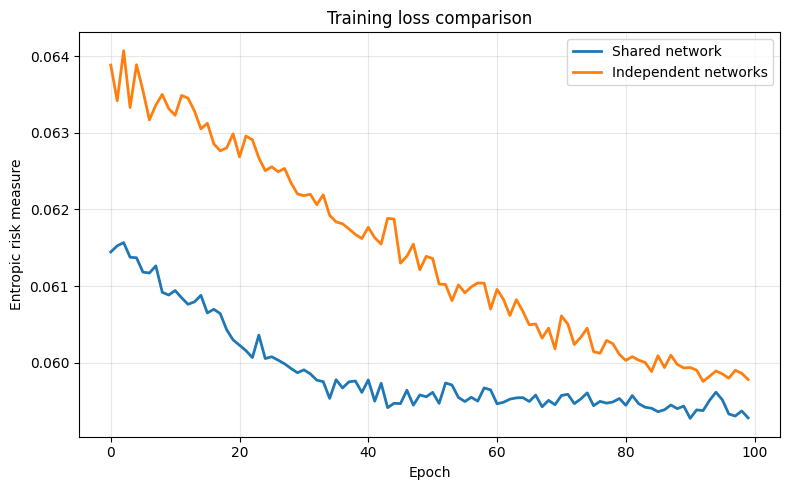

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(history1, label="Shared network", linewidth=2)
plt.plot(historyN, label="Independent networks", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Entropic risk measure")
plt.title("Training loss comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
def to_numpy(tensor: torch.Tensor) -> np.array:
    return tensor.detach().numpy()

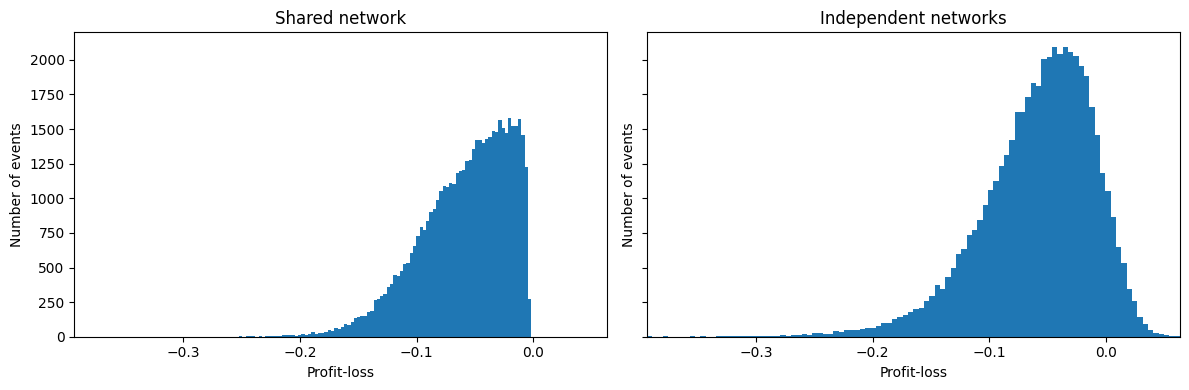

In [40]:

with torch.no_grad():
    pnl1 = hedger1.compute_pl(derivative).cpu()
    pnlN = hedgerN.compute_pl(derivative).cpu()

xmin = min(pnl1.min().item(), pnlN.min().item())
xmax = max(pnl1.max().item(), pnlN.max().item())

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4),
    sharex=True,
    sharey=True,
)

axes[0].hist(pnl1.numpy(), bins=100)
axes[0].set_title("Shared network")

axes[1].hist(pnlN.numpy(), bins=100)
axes[1].set_title("Independent networks")

for ax in axes:
    ax.set_xlim(xmin, xmax)
    ax.set_xlabel("Profit-loss")
    ax.set_ylabel("Number of events")

plt.tight_layout()
plt.show()

In [41]:
model_ann = BlackScholes(derivative)
hedger_ann = Hedger(model_ann, inputs=model_ann.inputs())

price_bs = hedger_ann.price(derivative, n_paths=N_PATHS)
price1 = hedger1.price(derivative, n_paths=N_PATHS)
priceN = hedgerN.price(derivative, n_paths=N_PATHS)

print(f"Black-Scholes price*:\t\t{price_bs.item():.6f}")
print(f"Shared network price:\t\t{price1.item():.6f}")
print(f"Independent networks price:\t{priceN.item():.6f}")

Black-Scholes price*:		0.058710
Shared network price:		0.059394
Independent networks price:	0.059851


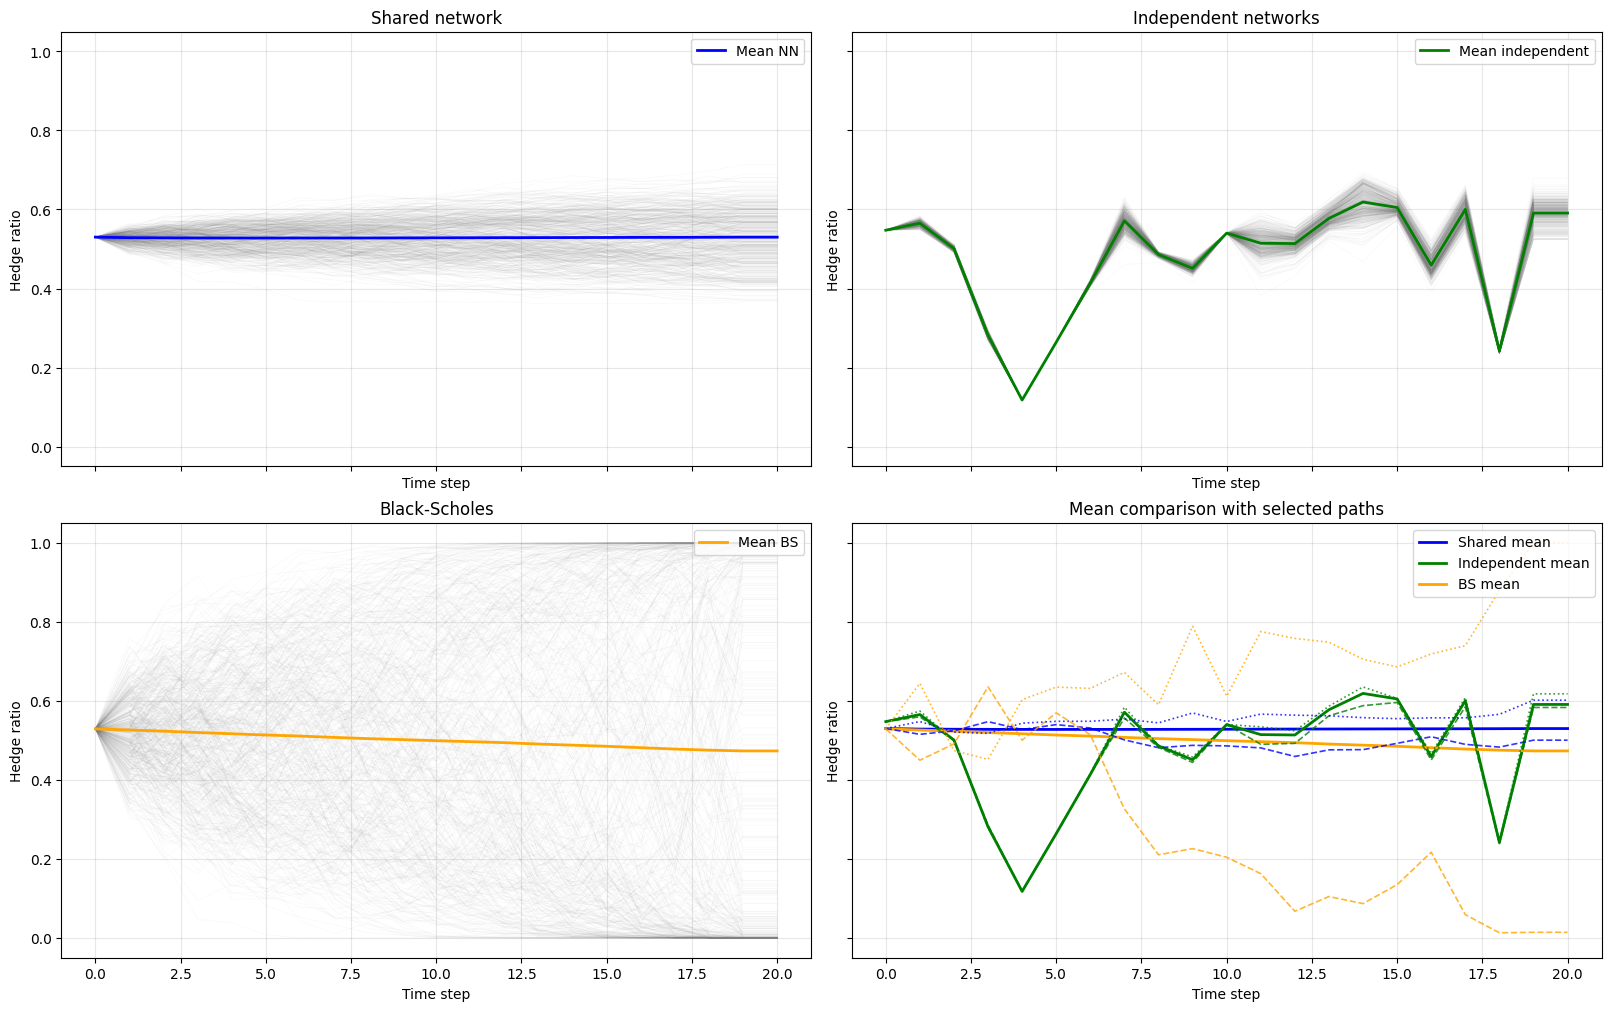

In [42]:
with torch.no_grad():
    delta_nn = hedger1.compute_hedge(derivative)[:, 0, :].cpu()
    delta_ind = hedgerN.compute_hedge(derivative)[:, 0, :].cpu()
    delta_bs = hedger_ann.compute_hedge(derivative)[:, 0, :].cpu()

time = np.arange(delta_nn.shape[1])
N_PLOT = 500

mean_nn = delta_nn.mean(dim=0)
mean_ind = delta_ind.mean(dim=0)
mean_bs = delta_bs.mean(dim=0)

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

# Shared network
for path in delta_nn[:N_PLOT]:
    axes[0, 0].plot(
        time, path,
        color="gray",
        alpha=0.05,
        linewidth=0.5,
    )

axes[0, 0].plot(
    time, mean_nn,
    color="blue",
    linewidth=2,
    label="Mean NN",
)
axes[0, 0].set_title("Shared network")
axes[0, 0].legend(loc="upper right")

# Independent networks
for path in delta_ind[:N_PLOT]:
    axes[0, 1].plot(
        time, path,
        color="gray",
        alpha=0.05,
        linewidth=0.5,
    )

axes[0, 1].plot(
    time, mean_ind,
    color="green",
    linewidth=2,
    label="Mean independent",
)
axes[0, 1].set_title("Independent networks")
axes[0, 1].legend(loc="upper right")

# Black-Scholes
for path in delta_bs[:N_PLOT]:
    axes[1, 0].plot(
        time, path,
        color="gray",
        alpha=0.05,
        linewidth=0.5,
    )

axes[1, 0].plot(
    time, mean_bs,
    color="orange",
    linewidth=2,
    label="Mean BS",
)
axes[1, 0].set_title("Black-Scholes")
axes[1, 0].legend(loc="upper right")

# Mean comparison and selected paths
ax = axes[1, 1]

ax.plot(
    time, mean_nn,
    color="blue",
    linewidth=2,
    label="Shared mean",
)

ax.plot(
    time, mean_ind,
    color="green",
    linewidth=2,
    label="Independent mean",
)

ax.plot(
    time, mean_bs,
    color="orange",
    linewidth=2,
    label="BS mean",
)

for path, style in zip([0, 1], ["--", ":"]):
    ax.plot(
        time,
        delta_nn[path],
        color="blue",
        linestyle=style,
        linewidth=1.2,
        alpha=0.8,
    )

    ax.plot(
        time,
        delta_ind[path],
        color="green",
        linestyle=style,
        linewidth=1.2,
        alpha=0.8,
    )

    ax.plot(
        time,
        delta_bs[path],
        color="orange",
        linestyle=style,
        linewidth=1.2,
        alpha=0.8,
    )

ax.set_title("Mean comparison with selected paths")
ax.legend(loc="upper right")

for ax in axes.flat:
    ax.set_xlabel("Time step")
    ax.set_ylabel("Hedge ratio")
    ax.grid(alpha=0.3)

plt.show()

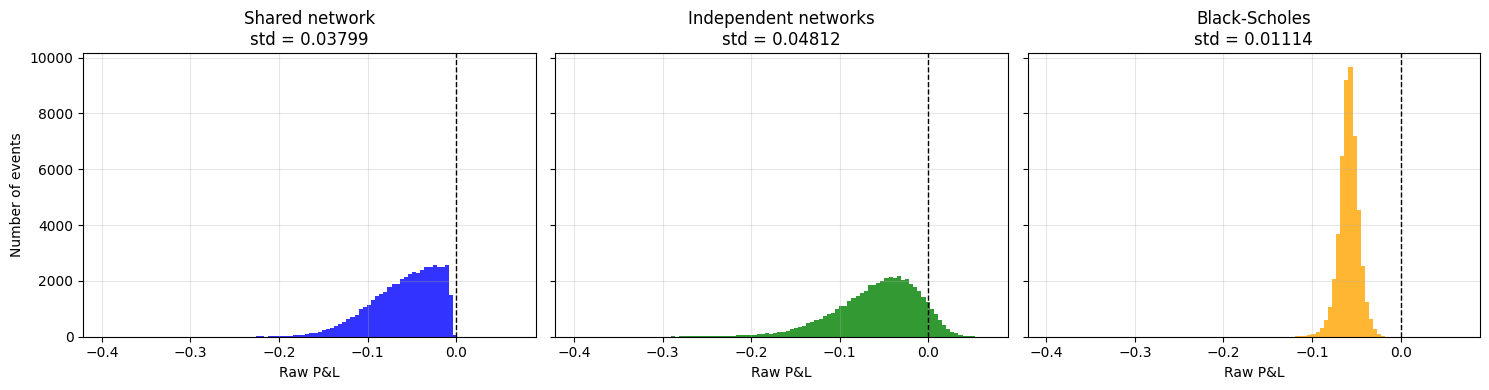

In [43]:
with torch.no_grad():
    pnl_nn = hedger1.compute_pl(derivative).cpu()
    pnl_ind = hedgerN.compute_pl(derivative).cpu()
    pnl_bs = hedger_ann.compute_pl(derivative).cpu()

all_pnl = torch.cat([pnl_nn, pnl_ind, pnl_bs])
xmin, xmax = all_pnl.min().item(), all_pnl.max().item()
bins = np.linspace(xmin, xmax, 101)

pnls = [
    (pnl_nn, "Shared network", "blue"),
    (pnl_ind, "Independent networks", "green"),
    (pnl_bs, "Black-Scholes", "orange"),
]

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 4),
    sharex=True,
    sharey=True,
)

for ax, (pnl, label, color) in zip(axes, pnls):
    ax.hist(pnl.numpy(), bins=bins, color=color, alpha=0.8)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{label}\nstd = {pnl.std():.5f}")
    ax.set_xlabel("Raw P&L")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Number of events")

plt.tight_layout()
plt.show()